# Assignment 5 — Data Preparation and Exploratory Data Analysis (EDA)

This notebook documents a thesis-oriented EDA for the GP practice population dataset used in the project.  
The analysis is intentionally **methodological, not only visual**: every section interprets what the observed properties imply for data quality, modeling risk, and the experimental design planned for Assignment 6.

## Scope and data used

Two related datasets are inspected:

1. **Raw demographics table** (`assignment4/data/raw/gp_practice_population_demographics_merged.xlsx`) — the substantive source used for rigorous structural and statistical analysis.
2. **Analytical sample dataset with target** (`assignment4/data/processed/gp_practice_analysis_dataset.csv`) — the currently available modeling table in the repository, used only to inspect the configured target variable and feature-target dependencies.

> Important limitation: the analytical dataset with the target variable is a tiny reproducibility bundle prepared in Assignment 4.  
> Therefore, target-level conclusions are treated here as **provisional and non-generalizable**, while the strongest evidence in this EDA comes from the full raw demographics table.

All figures are shown inside the notebook **and** saved to `assignment5/figures/` via `savefig()`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

cwd = Path.cwd()
if (cwd / "assignment4").exists():
    BASE_DIR = cwd
elif (cwd.parent / "assignment4").exists():
    BASE_DIR = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project root containing assignment4/")

RAW_PATH = BASE_DIR / "assignment4" / "data" / "raw" / "gp_practice_population_demographics_merged.xlsx"
ANALYTICAL_PATH = BASE_DIR / "assignment4" / "data" / "processed" / "gp_practice_analysis_dataset.csv"
FIG_DIR = BASE_DIR / "assignment5" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(BASE_DIR)}")
    return path

def plot_corr(ax, corr, title: str):
    image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    return image

def compute_vif(frame: pd.DataFrame) -> pd.Series:
    values = frame.astype(float).to_numpy()
    result = {}
    for idx, column in enumerate(frame.columns):
        y = values[:, idx]
        x = np.delete(values, idx, axis=1)
        x = np.column_stack([np.ones(len(frame)), x])
        beta, *_ = np.linalg.lstsq(x, y, rcond=None)
        y_hat = x @ beta
        ss_res = float(np.sum((y - y_hat) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 0.0 if ss_tot == 0 else 1 - ss_res / ss_tot
        result[column] = np.inf if 1 - r2 <= 1e-10 else 1 / (1 - r2)
    return pd.Series(result).sort_values(ascending=False)

raw_df = pd.read_excel(RAW_PATH, sheet_name="data")
raw_df["Date"] = pd.to_datetime(raw_df["Date"])

analytical_df = pd.read_csv(ANALYTICAL_PATH)
analytical_df["Date"] = pd.to_datetime(analytical_df["Date"])

expected_sex = {"All", "Female", "Male"}
qf_cols = [column for column in raw_df.columns if column.lower().endswith("qf")]
numeric_cols = [
    "AllAges",
    "Ages0to4",
    "Ages5to14",
    "Ages15to24",
    "Ages25to44",
    "Ages45to64",
    "Ages65to74",
    "Ages75to84",
    "Ages85plus",
]
age_band_cols = [column for column in numeric_cols if column != "AllAges"]

for column in numeric_cols:
    raw_df[column] = pd.to_numeric(raw_df[column], errors="coerce")

all_df = raw_df.loc[raw_df["Sex"] == "All"].copy()
all_df["share_age_0_14"] = (all_df["Ages0to4"] + all_df["Ages5to14"]) / all_df["AllAges"]
all_df["share_age_15_24"] = all_df["Ages15to24"] / all_df["AllAges"]
all_df["share_age_25_44"] = all_df["Ages25to44"] / all_df["AllAges"]
all_df["share_age_45_64"] = all_df["Ages45to64"] / all_df["AllAges"]
all_df["share_age_65_plus"] = (all_df["Ages65to74"] + all_df["Ages75to84"] + all_df["Ages85plus"]) / all_df["AllAges"]

print("Raw demographics dataset:", raw_df.shape)
print("Analytical dataset with target:", analytical_df.shape)
print("Figures directory:", FIG_DIR.relative_to(BASE_DIR))


Raw demographics dataset: (83391, 23)
Analytical dataset with target: (12, 20)
Figures directory: assignment5\figures


## A. Dataset Structure and Integrity Analysis

The raw demographics table contains **83,391 rows** and **23 columns**, covering the period from **2014-01-01** to **2021-07-01**.  
It has a clear **panel structure**: repeated measurements by **practice × date × sex**. The table includes **1,082 unique GP practices**, **29 reporting dates**, and three sex categories (`All`, `Female`, `Male`).

In terms of feature types, the raw table contains **1 datetime field** (`Date`), **1 practice identifier** (`PracticeCode`), **3 substantive categorical descriptors** (`HB`, `HSCP`, `Sex`), **9 quantitative population-count variables** (`AllAges` plus eight age-band counts), and **9 `QF` quality-flag metadata fields**. The main raw source is stored as **Excel (`.xlsx`, sheet `data`)**, whereas the currently available analytical sample with the target is stored as **CSV**.

For modeling purposes, the most informative unit is the `Sex = All` subset, because it represents the practice-level population without duplicating each practice-date combination across sex-specific rows.  
The separate sex rows remain useful for consistency checking and for deriving the female share, but they should not be mixed naively with the aggregate row during training.

The analytical dataset currently available in the repository has **12 rows** and **20 columns**. It is suitable for checking the configured target variable structure, but not for drawing substantive conclusions about the thesis problem because it is only a reproducibility sample.


Dataset profile:

                      dataset  rows  columns   date_min   date_max  unique_practices  unique_hb  unique_hscp
             raw_demographics 83391       23 2014-01-01 2021-07-01              1082         16           33
analytical_sample_with_target    12       20 2024-01-01 2024-03-01                 4          3            4

Integrity checks:
- fully duplicated rows: 0
- duplicated Date-PracticeCode-Sex keys: 0
- invalid sex labels outside {All, Female, Male}: []
- negative numeric values across demographic counts: 0
- Sex='All' rows with AllAges <= 0: 2
- Sex='All' rows where age bands do not sum to AllAges: 256
- incomplete sex bundles per (Date, PracticeCode): 9
- complete triplets where All != Female + Male: 0

Missing values by column (%), top 12:
Ages85PlusQF    99.089
Ages25To44QF    99.089
Ages75To84QF    99.089
Ages65To74QF    99.089
Ages0To4QF      99.089
Ages45To64QF    99.089
Ages5To14QF     99.089
Ages15To24QF    99.089
SexQF           66.663
Ages85plus 

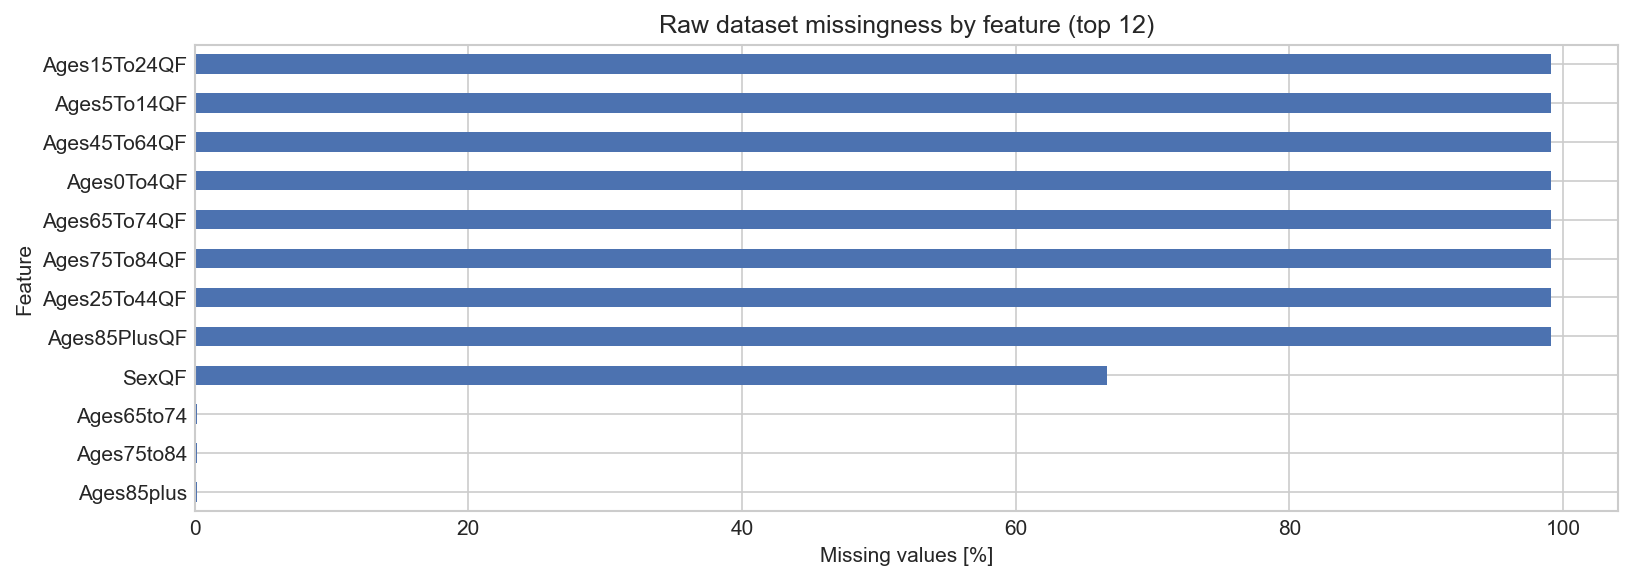

In [2]:
raw_profile = pd.DataFrame(
    [
        {
            "dataset": "raw_demographics",
            "rows": len(raw_df),
            "columns": raw_df.shape[1],
            "date_min": raw_df["Date"].min().date(),
            "date_max": raw_df["Date"].max().date(),
            "unique_practices": raw_df["PracticeCode"].nunique(),
            "unique_hb": raw_df["HB"].nunique(),
            "unique_hscp": raw_df["HSCP"].nunique(),
        },
        {
            "dataset": "analytical_sample_with_target",
            "rows": len(analytical_df),
            "columns": analytical_df.shape[1],
            "date_min": analytical_df["Date"].min().date(),
            "date_max": analytical_df["Date"].max().date(),
            "unique_practices": analytical_df["PracticeCode"].nunique(),
            "unique_hb": analytical_df["HB"].nunique(),
            "unique_hscp": analytical_df["HSCP"].nunique(),
        },
    ]
)
print("Dataset profile:\n")
print(raw_profile.to_string(index=False))

missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)
duplicate_rows_raw = int(raw_df.duplicated().sum())
duplicate_keys_raw = int(raw_df.duplicated(subset=["Date", "PracticeCode", "Sex"]).sum())
negative_counts = pd.Series({col: int((raw_df[col] < 0).fillna(False).sum()) for col in numeric_cols})
zero_allages_count = int((all_df["AllAges"] <= 0).sum())
invalid_sex_labels = sorted(set(raw_df["Sex"].dropna()) - expected_sex)
age_sum_mismatch = int((all_df[age_band_cols].sum(axis=1).round(6) != all_df["AllAges"].round(6)).sum())

sex_bundle = raw_df.groupby(["Date", "PracticeCode"])["Sex"].agg(lambda s: tuple(sorted(set(s.dropna()))))
incomplete_sex_bundle = sex_bundle[sex_bundle.apply(lambda value: set(value) != expected_sex)]

triples = raw_df.pivot_table(index=["Date", "PracticeCode"], columns="Sex", values="AllAges", aggfunc="first")
complete_triples = triples.dropna(subset=["All", "Female", "Male"])
reconciliation_diff = complete_triples["All"] - (complete_triples["Female"] + complete_triples["Male"])
reconciliation_mismatch = reconciliation_diff[reconciliation_diff != 0]

print("\nIntegrity checks:")
print(f"- fully duplicated rows: {duplicate_rows_raw}")
print(f"- duplicated Date-PracticeCode-Sex keys: {duplicate_keys_raw}")
print(f"- invalid sex labels outside {{All, Female, Male}}: {invalid_sex_labels}")
print(f"- negative numeric values across demographic counts: {int(negative_counts.sum())}")
print(f"- Sex='All' rows with AllAges <= 0: {zero_allages_count}")
print(f"- Sex='All' rows where age bands do not sum to AllAges: {age_sum_mismatch}")
print(f"- incomplete sex bundles per (Date, PracticeCode): {len(incomplete_sex_bundle)}")
print(f"- complete triplets where All != Female + Male: {len(reconciliation_mismatch)}")

print("\nMissing values by column (%), top 12:")
print(missing_pct.head(12).round(3).to_string())

if len(incomplete_sex_bundle) > 0:
    print("\nExample incomplete sex bundles:")
    print(incomplete_sex_bundle.head(10).to_string())

nonzero_missing = missing_pct[missing_pct > 0]
fig, ax = plt.subplots(figsize=(11, 4))
nonzero_missing.head(12).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Raw dataset missingness by feature (top 12)")
ax.set_xlabel("Missing values [%]")
ax.set_ylabel("Feature")
fig.tight_layout()
save_figure(fig, "01_raw_missingness.png")
plt.show()


**Interpretation.** The integrity checks indicate that the substantive demographic fields are structurally strong enough for analysis:

- No evidence of row duplication was found at the full-row level (**0**) or at the key level (`Date`, `PracticeCode`, `Sex`) (**0**).
- Age-band arithmetic is internally consistent for the aggregate rows: the count of `Sex = All` records where age bands fail to sum to `AllAges` is **256**.
- The main data-quality issue is concentrated in the `QF` metadata columns, whose average missingness is approximately **95.49%**. By contrast, the worst missingness among non-`QF` variables is only **0.144%**.
- A small number of practice-date groups (**9**) have an incomplete `Sex` triplet, and **0** complete triplets fail the identity `All = Female + Male`. These cases do not invalidate the whole dataset, but they matter because they show that derived sex-share features should be built only after explicit consistency checks.
- Records with `AllAges <= 0` exist but are extremely rare (**2** rows in the aggregate table), so they should be filtered rather than treated as representative behavior.

Overall, the integrity profile **supports experimental validity** for demographic modeling, provided that `QF` fields are excluded from quantitative features and a small number of inconsistent practice-date-sex bundles are handled explicitly.


Categorical summary:

feature  cardinality most_common_category  largest_category_share_%
    Sex            3                  All                    33.337
     HB           16            S08000021                    19.160
   HSCP           33            S37000034                    15.271

Top 10 Health Boards in the aggregate table:
HB
S08000021    5326
S08000024    3563
S08000022    2856
S08000023    2376
S08000020    2168
S08000030    1880
S08000029    1651
S08000031    1646
S08000015    1614
S08000019    1601

Top 10 HSCP units in the aggregate table:
HSCP
S37000034    4245
S37000012    2125
S37000016    1905
S37000035    1615
S37000028    1471
S37000014    1270
S37000006     958
S37000004     951
S37000002     938
S37000001     852
Saved figure: assignment5\figures\02_categorical_structure.png


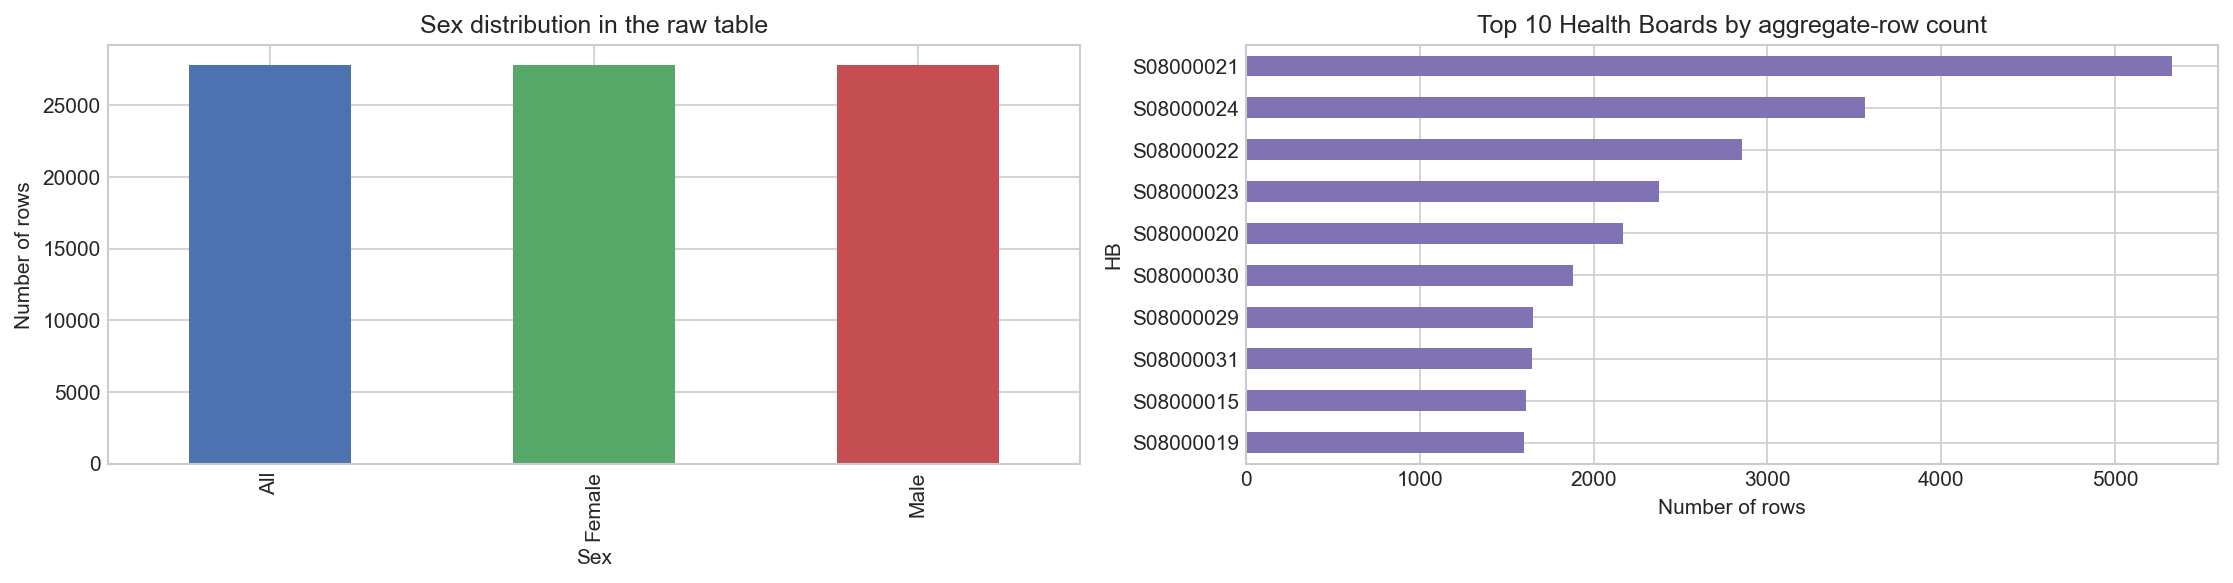

In [3]:
sex_counts = raw_df["Sex"].value_counts().reindex(["All", "Female", "Male"]).fillna(0).astype(int)
hb_counts = all_df["HB"].value_counts()
hscp_counts = all_df["HSCP"].value_counts()

categorical_summary = pd.DataFrame(
    [
        {
            "feature": "Sex",
            "cardinality": raw_df["Sex"].nunique(dropna=True),
            "most_common_category": sex_counts.idxmax(),
            "largest_category_share_%": round(sex_counts.max() / len(raw_df) * 100, 3),
        },
        {
            "feature": "HB",
            "cardinality": raw_df["HB"].nunique(dropna=True),
            "most_common_category": raw_df["HB"].value_counts().idxmax(),
            "largest_category_share_%": round(raw_df["HB"].value_counts(normalize=True).max() * 100, 3),
        },
        {
            "feature": "HSCP",
            "cardinality": raw_df["HSCP"].nunique(dropna=True),
            "most_common_category": raw_df["HSCP"].value_counts().idxmax(),
            "largest_category_share_%": round(raw_df["HSCP"].value_counts(normalize=True).max() * 100, 3),
        },
    ]
)

print("Categorical summary:\n")
print(categorical_summary.to_string(index=False))
print("\nTop 10 Health Boards in the aggregate table:")
print(hb_counts.head(10).to_string())
print("\nTop 10 HSCP units in the aggregate table:")
print(hscp_counts.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sex_counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Sex distribution in the raw table")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Number of rows")

hb_counts.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#8172B3")
axes[1].set_title("Top 10 Health Boards by aggregate-row count")
axes[1].set_xlabel("Number of rows")
axes[1].set_ylabel("HB")

fig.tight_layout()
save_figure(fig, "02_categorical_structure.png")
plt.show()


## B. Statistical Characterization

The categorical structure is **not uniformly balanced**, but the imbalance is interpretable rather than pathological.

- `Sex` is close to balanced at the row level because the data are organized around the reporting convention `All` / `Female` / `Male`. This balance is structural, not inferential.
- Regional variables are less balanced. The raw table contains **16 Health Boards** and **33 HSCP units**, with the largest HB contributing **19.16%** of rows. This means regional comparisons must be interpreted with unequal support.
- Because `HSCP` is more granular than `HB`, using both variables simultaneously may improve control for location, but it also increases sparsity and the risk of redundant encoding.

In short, the dataset is **structurally balanced by sex but not by geography**. This does not require class rebalancing (the thesis task is regression, not classification), but it does justify careful regularization and explicit regional controls.


Numerical summary for the aggregate practice-level table:

                mean  median           var    skew  min      max
AllAges     5931.154  5494.5  1.384343e+07   1.545  0.0  48657.0
Ages0to4     288.715   263.0  3.769737e+04   1.257  0.0   1475.0
Ages5to14    617.874   559.0  1.634013e+05   1.121  0.0   3157.0
Ages15to24   711.670   598.0  6.611266e+05  10.036  0.0  17152.0
Ages25to44  1624.964  1431.0  1.503129e+06   3.826  0.0  26660.0
Ages45to64  1635.409  1512.0  9.548444e+05   0.894  0.0   6789.0
Ages65to74   593.466   527.0  1.424213e+05   0.990  0.0   2676.0
Ages75to84   341.938   298.0  4.958912e+04   0.972  0.0   1543.0
Ages85plus   124.317   105.0  7.940278e+03   1.342  0.0   1136.0

AllAges quantiles:
0.25     3173.00
0.50     5494.50
0.75     8180.25
0.95    12239.00
0.99    17557.18
Saved figure: assignment5\figures\03_allages_distribution.png


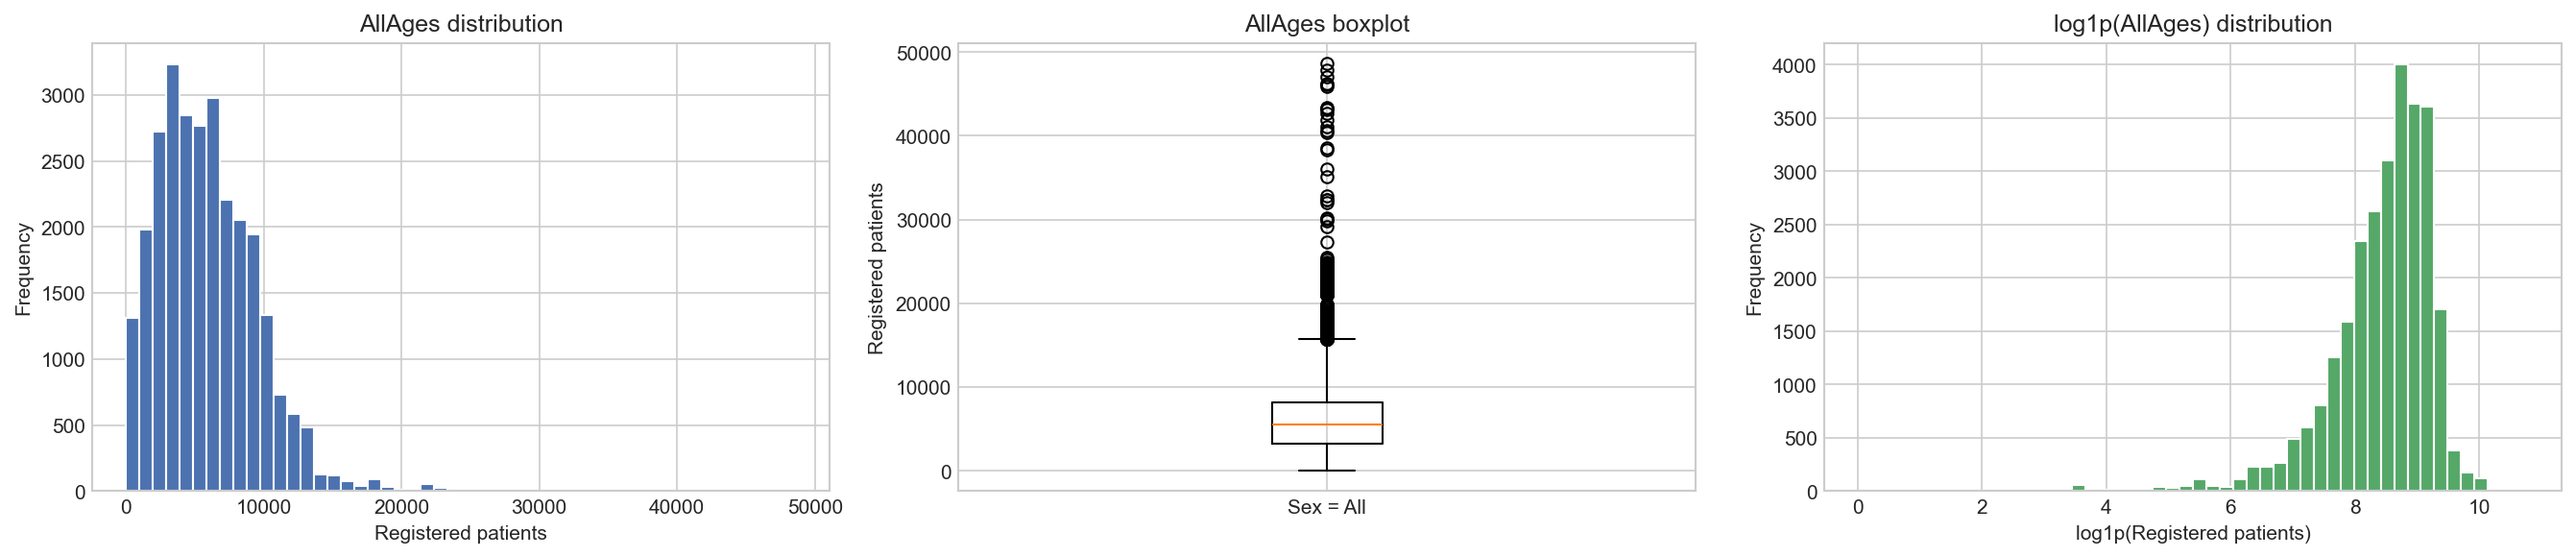

In [4]:
numerical_summary = all_df[numeric_cols].agg(["mean", "median", "var", "skew", "min", "max"]).T
allages_quantiles = all_df["AllAges"].quantile([0.25, 0.50, 0.75, 0.95, 0.99])

print("Numerical summary for the aggregate practice-level table:\n")
print(numerical_summary.round(3).to_string())
print("\nAllAges quantiles:")
print(allages_quantiles.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(all_df["AllAges"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("AllAges distribution")
axes[0].set_xlabel("Registered patients")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(all_df["AllAges"].dropna(), vert=True)
axes[1].set_title("AllAges boxplot")
axes[1].set_ylabel("Registered patients")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Sex = All"])

axes[2].hist(np.log1p(all_df["AllAges"].dropna()), bins=50, color="#55A868", edgecolor="white")
axes[2].set_title("log1p(AllAges) distribution")
axes[2].set_xlabel("log1p(Registered patients)")
axes[2].set_ylabel("Frequency")

fig.tight_layout()
save_figure(fig, "03_allages_distribution.png")
plt.show()


For the core numerical variables, the aggregate practice-level population size is clearly **right-skewed**:

- `AllAges` has mean **5,931.2** and median **5,494.5**, so the mean exceeds the median.
- The skewness of `AllAges` is **1.545**, confirming a long upper tail.
- The 99th percentile is approximately **17,557** patients, far above the typical practice size.

This matters for modeling because untransformed absolute counts can dominate linear estimators and make coefficients sensitive to a relatively small number of very large practices.  
As a result, **log transformation, robust scaling, or sensitivity checks with and without the largest practices** should be considered in Assignment 6.


Analytical sample used for target inspection:

      Date  PracticeCode                  HB            HSCP  AllAges  gp_availability  share_age_65_plus  share_female  deprivation_index  hospital_use_per_1000
2024-01-01          1001         NHS_Lothian Edinburgh_North     5400             0.68           0.185185      0.516667               18.2                  268.4
2024-01-01          1002         NHS_Lothian  Edinburgh_West     4300             0.63           0.183721      0.519767               24.9                  286.7
2024-01-01          1003 NHS_Greater_Glasgow Glasgow_Central     6100             0.51           0.155738      0.525410               41.3                  347.9
2024-01-01          1004        NHS_Grampian   Aberdeen_City     3900             0.73           0.205128      0.516667               20.8                  248.6
2024-02-01          1001         NHS_Lothian Edinburgh_North     5425             0.69           0.184885      0.516498               18.1     

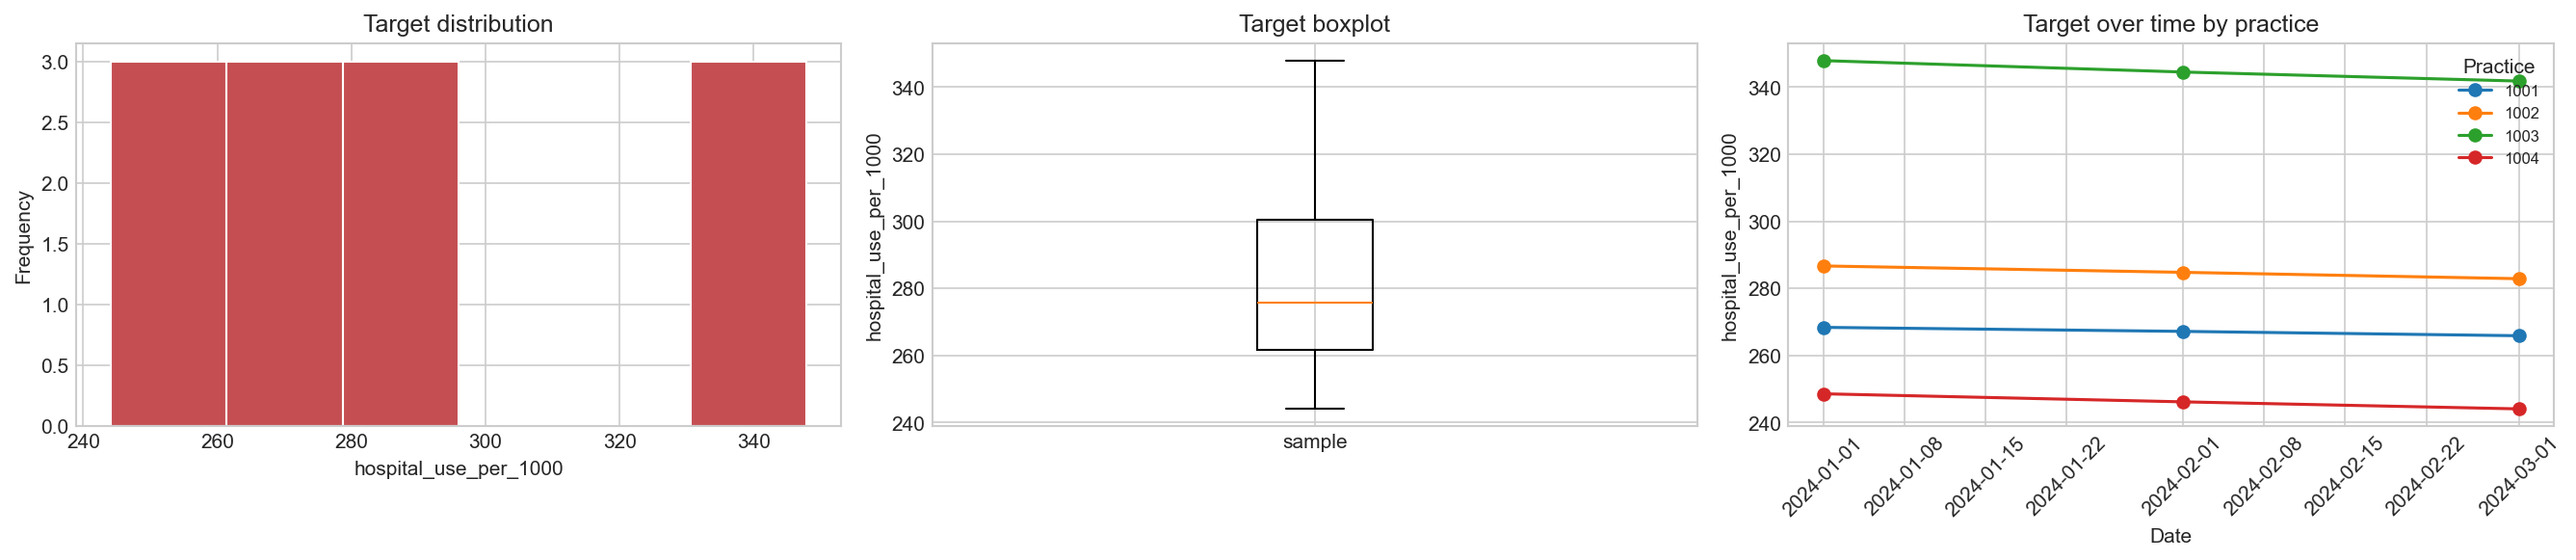

In [5]:
target_col = "hospital_use_per_1000"
model_feature_cols = ["AllAges", "gp_availability", "share_age_65_plus", "share_female", "deprivation_index"]
target_summary = analytical_df[target_col].agg(["count", "mean", "median", "std", "min", "max"])
target_cv = analytical_df[target_col].std() / analytical_df[target_col].mean()

print("Analytical sample used for target inspection:\n")
print(analytical_df[["Date", "PracticeCode", "HB", "HSCP"] + model_feature_cols + [target_col]].to_string(index=False))
print("\nTarget summary:")
print(target_summary.round(3).to_string())
print(f"\nCoefficient of variation for the target: {target_cv:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(analytical_df[target_col], bins=6, color="#C44E52", edgecolor="white")
axes[0].set_title("Target distribution")
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(analytical_df[target_col], vert=True)
axes[1].set_title("Target boxplot")
axes[1].set_ylabel(target_col)
axes[1].set_xticks([1])
axes[1].set_xticklabels(["sample"])

for practice_code, subset in analytical_df.groupby("PracticeCode"):
    subset = subset.sort_values("Date")
    axes[2].plot(subset["Date"], subset[target_col], marker="o", label=str(practice_code))
axes[2].set_title("Target over time by practice")
axes[2].set_xlabel("Date")
axes[2].set_ylabel(target_col)
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Practice", fontsize=8)

fig.tight_layout()
save_figure(fig, "04_target_distribution_sample.png")
plt.show()


### Target variable structure

The configured target is a **continuous regression outcome**: `hospital_use_per_1000`.  
Therefore, the relevant question is not class imbalance but **distributional spread and stability**.

- In the repository sample, the target ranges from **244.1** to **347.9**.
- The coefficient of variation is **0.134**, which suggests moderate relative spread in the sample.
- However, the sample contains only **12 rows** covering **4 practices** and **3 months**.

This remains **consistent with Assignment 3 in target type**: the planned response variable is continuous hospital-use intensity rather than a classification label. At the same time, the currently committed Assignment 4 sample is far smaller than the substantive thesis dataset anticipated in Assignment 3, so target-level conclusions here must remain provisional.

Methodologically, this means that **resampling methods for imbalance are not the issue**; the issue is the lack of representativeness of the current target table.  
The target analysis is useful for verifying pipeline structure, but it is **insufficient for final model choice or substantive regression assumptions** until the full real outcome table is available.


Correlation matrix for aggregate age shares:

                   share_age_0_14  share_age_15_24  share_age_25_44  share_age_45_64  share_age_65_plus
share_age_0_14              1.000           -0.174            0.007            0.318             -0.063
share_age_15_24            -0.174            1.000            0.381           -0.428             -0.393
share_age_25_44             0.007            0.381            1.000           -0.437             -0.669
share_age_45_64             0.318           -0.428           -0.437            1.000              0.666
share_age_65_plus          -0.063           -0.393           -0.669            0.666              1.000

Correlation matrix for the analytical sample (numeric features + target):

                       AllAges  gp_availability  share_age_65_plus  share_female  deprivation_index  hospital_use_per_1000
AllAges                  1.000           -0.764             -0.887         0.655              0.654                  0.790
gp_avail

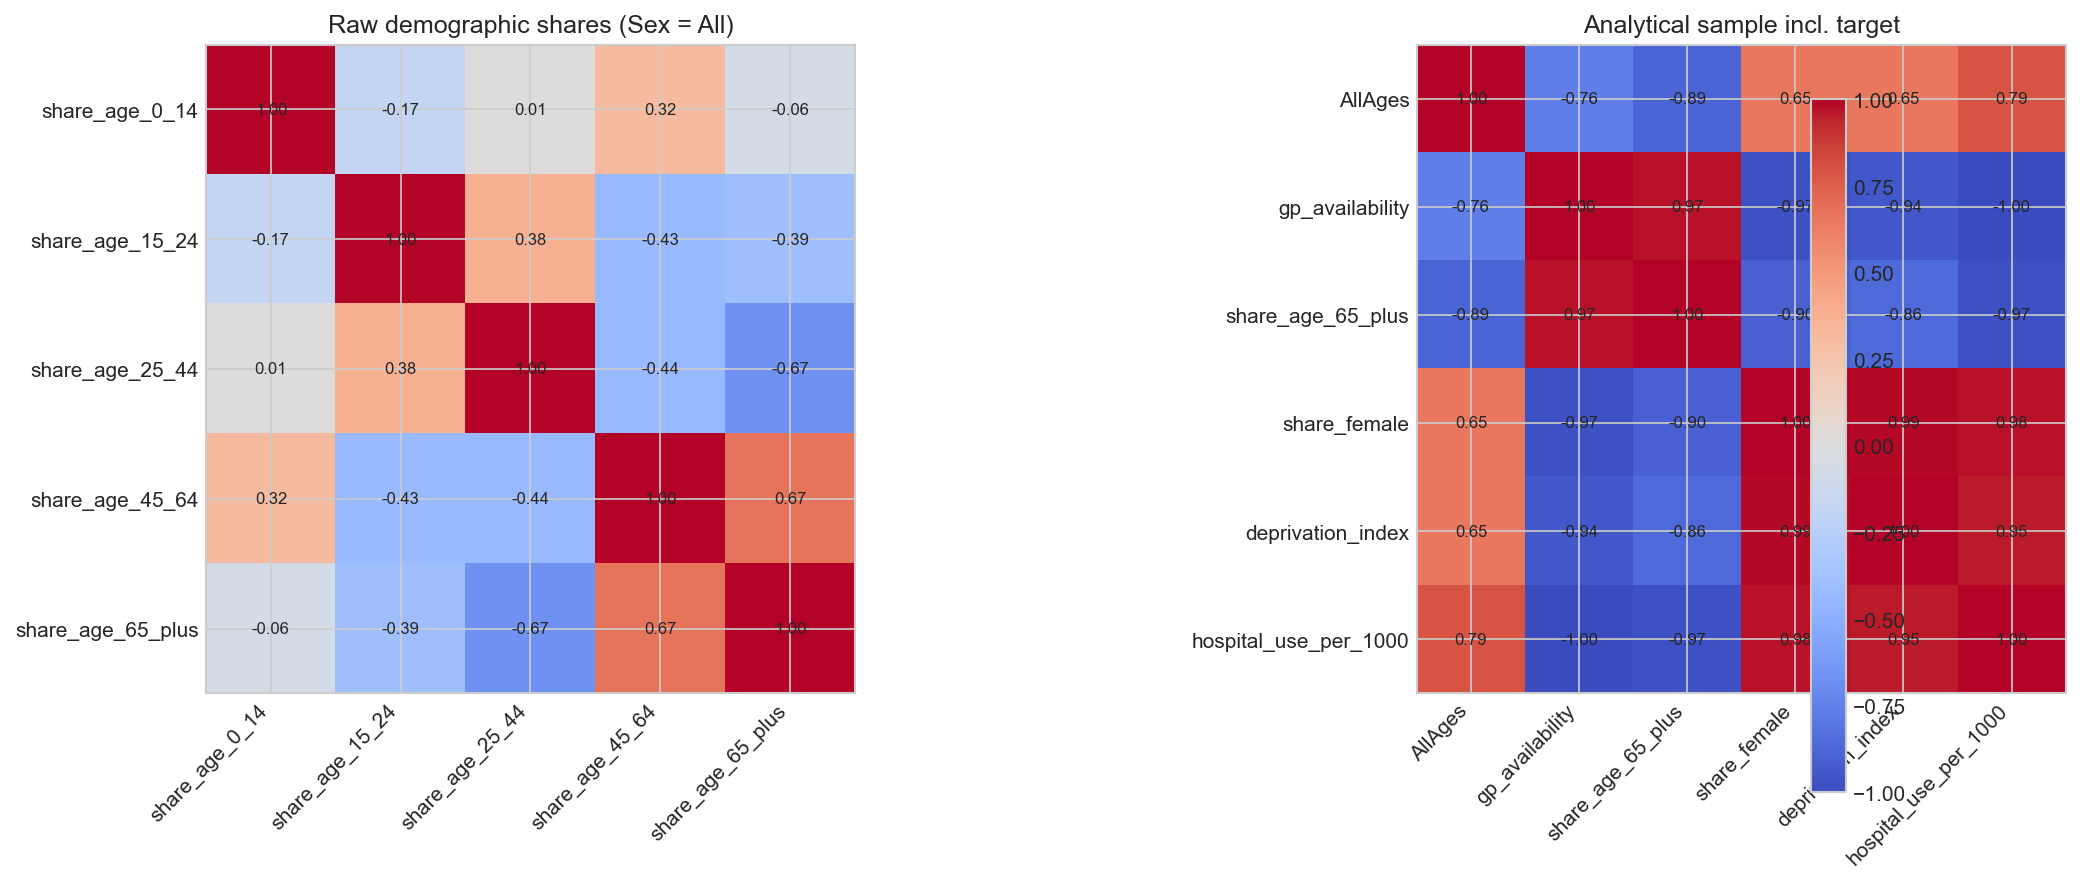

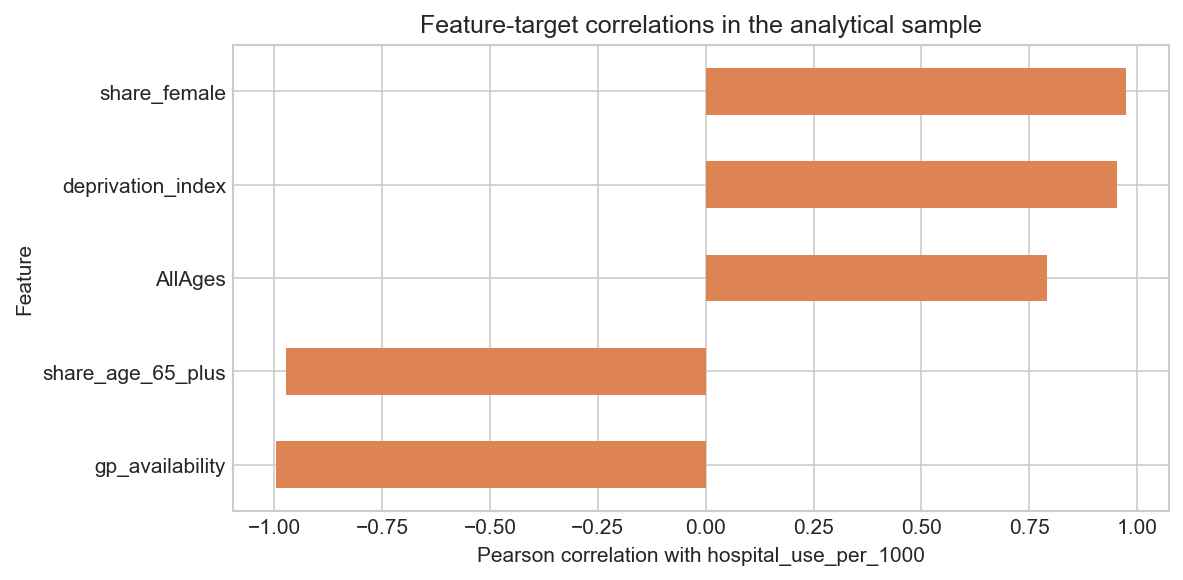

In [6]:
raw_share_cols = ["share_age_0_14", "share_age_15_24", "share_age_25_44", "share_age_45_64", "share_age_65_plus"]
target_col = "hospital_use_per_1000"
model_feature_cols = ["AllAges", "gp_availability", "share_age_65_plus", "share_female", "deprivation_index"]

raw_share_corr = all_df[raw_share_cols].corr()
sample_corr = analytical_df[model_feature_cols + [target_col]].corr()
target_correlations = sample_corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
vif_summary = compute_vif(analytical_df[model_feature_cols])

print("Correlation matrix for aggregate age shares:\n")
print(raw_share_corr.round(3).to_string())
print("\nCorrelation matrix for the analytical sample (numeric features + target):\n")
print(sample_corr.round(3).to_string())
print("\nFeature-target correlations in the analytical sample:\n")
print(target_correlations.round(3).to_string())
print("\nApproximate VIF values for numeric modeling features:\n")
print(vif_summary.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
image = plot_corr(axes[0], raw_share_corr, "Raw demographic shares (Sex = All)")
plot_corr(axes[1], sample_corr, "Analytical sample incl. target")
fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
fig.tight_layout()
save_figure(fig, "05_correlation_heatmaps.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
target_correlations.sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Feature-target correlations in the analytical sample")
ax.set_xlabel("Pearson correlation with hospital_use_per_1000")
ax.set_ylabel("Feature")
fig.tight_layout()
save_figure(fig, "06_feature_target_correlations.png")
plt.show()


## C. Correlation and Dependency Analysis

Three methodological points are especially important.

1. **Compositional dependence in age shares.** The raw age-share matrix contains strong dependencies because the shares describe parts of the same population. The strongest absolute relationship is between **`share_age_25_44`** and **`share_age_65_plus`** (|r| = **0.669**). This is expected in compositional data and implies that including many related shares simultaneously may create redundancy.
2. **Feature-target relationships in the repository sample are only provisional.** In the analytical sample, the strongest observed linear relationship with the target is **`gp_availability`** (r = **-0.996**). This can help check whether the pipeline is wired correctly, but it should not be treated as empirical evidence for the thesis because the target table is only a tiny synthetic sample.
3. **Multicollinearity is a real modeling risk.** The highest approximate VIF occurs for **`share_age_65_plus`** (VIF ≈ **697.53**). Even if this number is unstable because of the small sample, it reinforces a broader structural point: totals, shares, and nested geography variables can easily overlap in the information they encode.

### Leakage and redundancy risks

- `HB` and `HSCP` are hierarchically related, so one-hot encoding both may introduce quasi-duplication.
- Practice observations repeat over time; therefore, a random row-wise split can leak practice-specific structure from train to test.
- Raw age counts and derived shares should not be combined indiscriminately, because they are algebraically connected through `AllAges`.

This section supports a later feature-engineering strategy based on **parsimonious derived shares, careful regional encoding, and leakage-aware validation**.


Outlier analysis using the IQR rule on AllAges:
- Q1: 3173.000
- Q3: 8180.250
- IQR: 5007.250
- lower bound: -4337.875
- upper bound: 15691.125
- outlier rows: 375 (1.349%)
- Spearman correlation between practice size and share_age_65_plus: -0.175

Largest outlier observations:
      Date  PracticeCode        HB      HSCP  AllAges
2021-07-01         43576 S08000031 S37000034  48657.0
2021-04-01         43576 S08000031 S37000034  47877.0
2021-01-01         43576 S08000031 S37000034  47049.0
2020-01-01         43576 S08000031 S37000034  46215.0
2020-04-01         43576 S08000031 S37000034  46086.0
2019-10-01         43576 S08000031 S37000034  45912.0
2019-01-01         43576 S08000021 S37000034  43368.0
2019-04-01         43576 S08000021 S37000034  43222.0
2019-07-01         43576 S08000031 S37000034  43164.0
2018-10-01         43576 S08000021 S37000034  42631.0
Saved figure: assignment5\figures\07_outliers_and_dependency.png


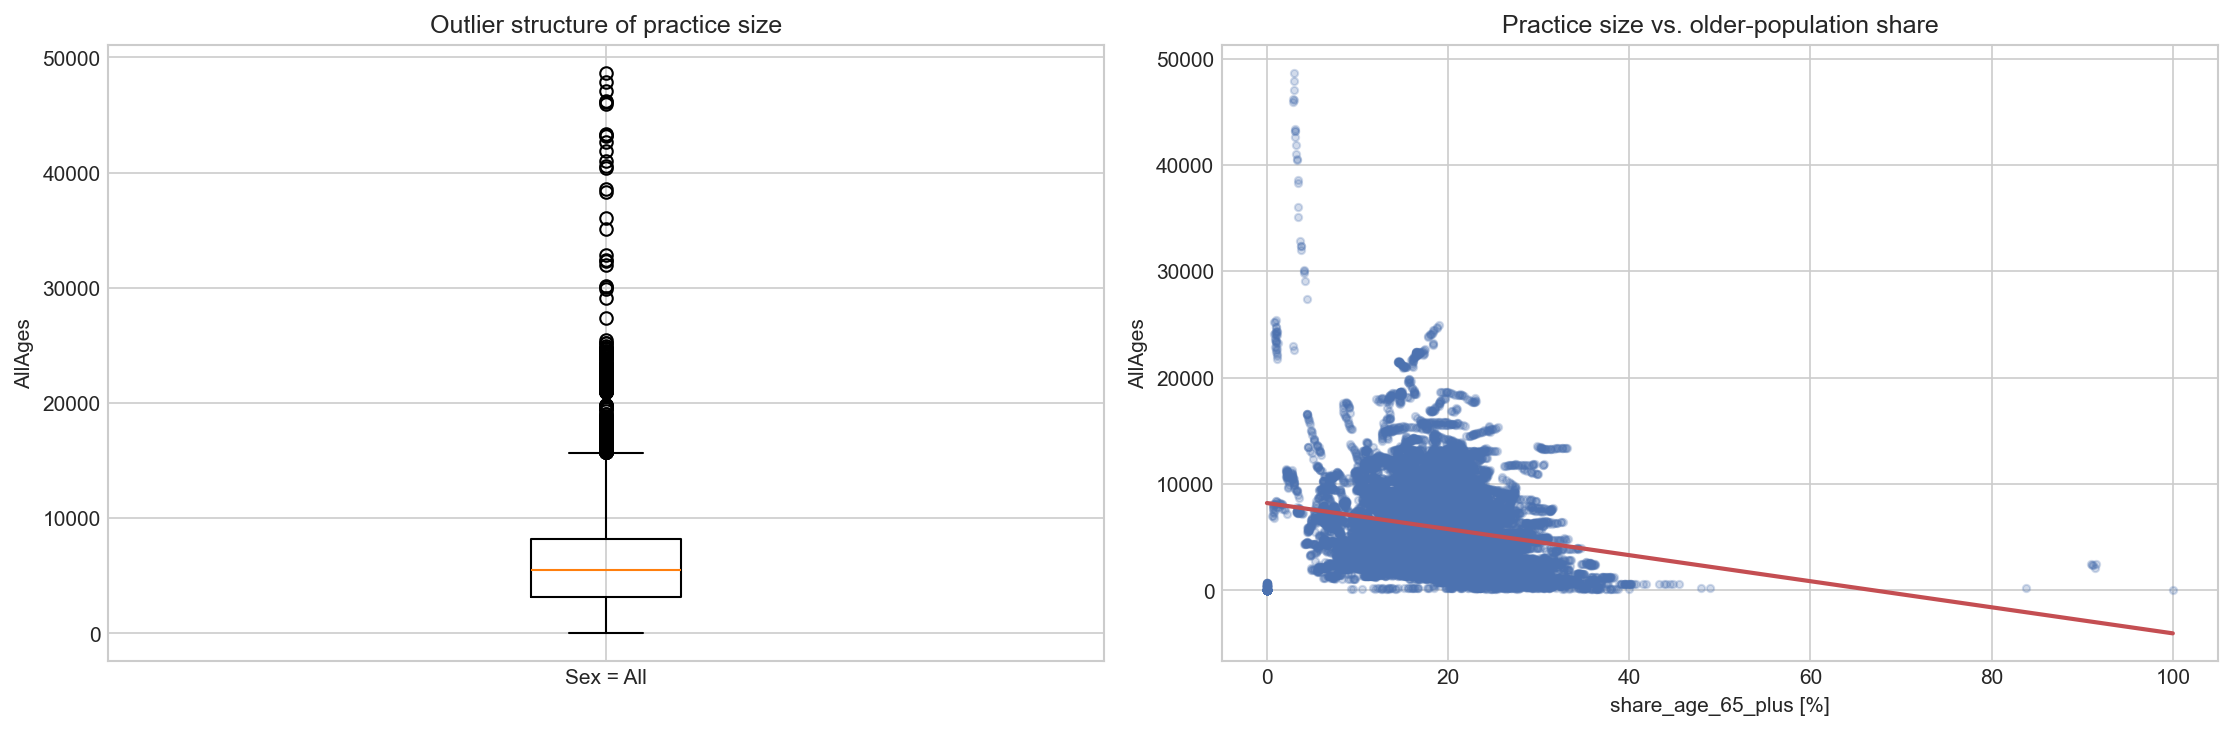

In [7]:
q1 = all_df["AllAges"].quantile(0.25)
q3 = all_df["AllAges"].quantile(0.75)
iqr = q3 - q1
low_bound = q1 - 1.5 * iqr
high_bound = q3 + 1.5 * iqr

outliers = all_df[(all_df["AllAges"] < low_bound) | (all_df["AllAges"] > high_bound)].copy()
outlier_rate = len(outliers) / len(all_df) * 100
top_outliers = outliers[["Date", "PracticeCode", "HB", "HSCP", "AllAges"]].sort_values("AllAges", ascending=False).head(10)

plot_df = all_df[["share_age_65_plus", "AllAges"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
spearman_size_age65 = plot_df.corr(method="spearman").iloc[0, 1]
line_coef = np.polyfit(plot_df["share_age_65_plus"], plot_df["AllAges"], deg=1)
x_line = np.linspace(plot_df["share_age_65_plus"].min(), plot_df["share_age_65_plus"].max(), 100)

print("Outlier analysis using the IQR rule on AllAges:")
print(f"- Q1: {q1:.3f}")
print(f"- Q3: {q3:.3f}")
print(f"- IQR: {iqr:.3f}")
print(f"- lower bound: {low_bound:.3f}")
print(f"- upper bound: {high_bound:.3f}")
print(f"- outlier rows: {len(outliers)} ({outlier_rate:.3f}%)")
print(f"- Spearman correlation between practice size and share_age_65_plus: {spearman_size_age65:.3f}")

print("\nLargest outlier observations:")
print(top_outliers.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].boxplot(all_df["AllAges"].dropna(), vert=True)
axes[0].set_title("Outlier structure of practice size")
axes[0].set_ylabel("AllAges")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["Sex = All"])

axes[1].scatter(plot_df["share_age_65_plus"] * 100, plot_df["AllAges"], alpha=0.25, s=12, color="#4C72B0")
axes[1].plot(x_line * 100, line_coef[0] * x_line + line_coef[1], color="#C44E52", linewidth=2)
axes[1].set_title("Practice size vs. older-population share")
axes[1].set_xlabel("share_age_65_plus [%]")
axes[1].set_ylabel("AllAges")

fig.tight_layout()
save_figure(fig, "07_outliers_and_dependency.png")
plt.show()


## D. Outlier and Noise Assessment

The `AllAges` variable contains **375 IQR-defined outlier rows**, which is **1.349%** of the aggregate table.  
This is not evidence of random noise; it mainly reflects a small group of structurally very large practices.

The negative Spearman association between practice size and the share of patients aged 65+ is **-0.175**.  
This suggests that some of the most extreme observations are not arbitrary errors but belong to a distinct demographic regime: larger practices often serve relatively younger populations.

### Recommended handling decision

- **Retain** the large-practice observations in the main dataset, because they represent real service units rather than obvious corruption.
- **Transform or robustify** the scale-sensitive variables (especially `AllAges`) for models that assume roughly homoscedastic numeric behavior.
- **Investigate** the few sex-inconsistency cases identified earlier before deriving sex-share features.
- **Do not claim label-noise detection** for the target at this stage, because the available target table is only a reproducibility sample.

In other words, the correct engineering response is **not indiscriminate deletion**, but controlled preprocessing plus sensitivity analysis.


## E. Bias and Limitation Analysis

This EDA reveals several constraints on generalizability.

### 1. Sampling and domain bias

- The raw demographics data describe **Scottish GP practices only**, so conclusions are domain-specific and should not be generalized automatically to other countries or healthcare systems.
- The observation window (**2014-01-01 to 2021-07-01**) spans substantial system changes, including the pandemic period. Temporal drift is therefore plausible.

### 2. Representativeness for the final modeling task

- The demographics table is large and operationally meaningful, so it is suitable for studying structure, missingness, and population composition.
- However, the target-bearing analytical table committed in the repository is **not representative of the thesis problem**. It contains only **12 rows**, **4 practices**, and **3 months**.
- Consequently, any feature-target findings observed here must be treated as **pipeline checks**, not as evidence about real hospital-use dynamics.

### 3. Structural bias in administrative data

- Administrative datasets are shaped by reporting rules, suppression flags, and data-collection boundaries. The heavily missing `QF` columns illustrate this directly.
- Repeated observations of the same practices create dependence over time; assuming independent rows would bias evaluation.

### 4. Ethical considerations

- The data are aggregated rather than person-level, so privacy risk is low.
- Nevertheless, variables related to deprivation and regional structure can encode entrenched social inequalities. Models must therefore be interpreted as descriptive tools for system variation, **not as normative judgments about practices or populations**.

These limitations do not invalidate the project, but they define its valid inference scope. Transparency about these boundaries is necessary for engineering rigor.


In [8]:
implications_df = pd.DataFrame(
    [
        {
            "EDA finding": "QF columns are almost entirely missing and act as metadata rather than usable predictors.",
            "Implication for Assignment 6": "Exclude QF fields from quantitative modeling unless a specific quality-flag use case is defined.",
        },
        {
            "EDA finding": "Practice size is strongly right-skewed and contains structurally large practices.",
            "Implication for Assignment 6": "Consider log transformation or robust scaling for size-related variables; avoid automatic outlier deletion.",
        },
        {
            "EDA finding": "Age shares are compositionally dependent.",
            "Implication for Assignment 6": "Use a compact derived feature set instead of many overlapping age shares or counts.",
        },
        {
            "EDA finding": "Rows are clustered by practice and repeated over time.",
            "Implication for Assignment 6": "Replace naive random splitting with time-aware and/or group-aware validation to reduce leakage.",
        },
        {
            "EDA finding": "HB and HSCP encode nested regional structure.",
            "Implication for Assignment 6": "Use regularized encoding and verify whether both levels are needed simultaneously.",
        },
        {
            "EDA finding": "The currently available target dataset is only a tiny reproducibility sample.",
            "Implication for Assignment 6": "Treat current target analyses as provisional and prioritize integration of the full real supporting tables before final experiments.",
        },
    ]
)

print("Implications for experimental design:\n")
print(implications_df.to_string(index=False))


Implications for experimental design:

                                                                              EDA finding                                                                                                         Implication for Assignment 6
QF columns are almost entirely missing and act as metadata rather than usable predictors.                                     Exclude QF fields from quantitative modeling unless a specific quality-flag use case is defined.
        Practice size is strongly right-skewed and contains structurally large practices.                          Consider log transformation or robust scaling for size-related variables; avoid automatic outlier deletion.
                                                Age shares are compositionally dependent.                                                  Use a compact derived feature set instead of many overlapping age shares or counts.
                                   Rows are clustered by practice and

## F. Implications for Experimental Design

The EDA largely **supports the central thesis assumption from Assignment 3** that demographic structure is meaningful: practices differ materially in age composition, size, and regional context, so there is a plausible basis for demographic predictors.

More specifically, the EDA is **consistent with the Assignment 3 F0/F1 logic**:

- the baseline idea behind **F0** (`AllAges` + `gp_availability`) remains coherent,
- the extended rationale behind **F1** (age structure, female share, deprivation, and region) is also supported,
- and the continuous target framing for `hospital_use_per_1000` is unchanged.

At the same time, the analysis **challenges one methodological assumption carried forward from Assignments 3 and 4**: the sufficiency of a simple shuffled row-wise **80/20 split** plus standard shuffled **5-fold cross-validation**. The data are longitudinal, regionally clustered, and partially compositional, so practice-level repetition creates leakage risk if train/test separation ignores the panel structure.

This is especially important because the current Assignment 4 implementation in `assignment4/src/modeling.py` uses `train_test_split(..., shuffle=True)` and `KFold(..., shuffle=True)`. The EDA therefore does not contradict the earlier work, but it **refines it**: Assignment 6 should consider time-aware and/or group-aware validation to better match the actual data-generating structure.

Therefore, Assignment 6 should refine the preprocessing and validation pipeline in the following direction:

- build features from the `Sex = All` table and derive compact shares intentionally,
- filter or flag the few inconsistent practice-date-sex bundles,
- treat size variables with transformation/robust scaling,
- replace naive row-wise splitting with leakage-aware validation strategies,
- and postpone strong target-level claims until the real outcome/support tables are integrated.

### Methodological reflection

This EDA does not function as decorative exploration. It directly informs the pipeline architecture:

- what should be removed (`QF` columns),
- what should be transformed (`AllAges` and related scale-sensitive variables),
- what should be encoded carefully (`HB`, `HSCP`),
- and what should be reconsidered in evaluation design (random row-wise splitting).

In that sense, the EDA both **confirms** the relevance of demographic structure and **refines** the experimental plan by making the main risks explicit before feature engineering begins.
